
### imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import cycxchg as cxc
import time
import scipy
from collections import defaultdict

# Mixing time for random minimum cycle bases (MCBs)
Given the eigenvalues $\lambda_1,\lambda_2,\ldots$ of the probability transition matrix for an ergodic Markov chain, the mixing time is bounded by ([Levin and Peres, 2017](https://bookstore.ams.org/mbk-107), available on [Levin's website](https://pages.uoregon.edu/dlevin/)):
$$t_{mix}(\epsilon)\le\left\lceil\frac{1}{\lambda_1-\lambda_2}\left(\frac{1}{2}\log\left(\frac{1}{\pi_{\min}}\right)+\log\left(\frac{1}{2\epsilon}\right)\right)\right\rceil,$$
where $\pi_{\min}$ is the minimum value of the stationary distribution $\pi$. 
Here, we investigate mixing time of the Markov chain Monte Carlo (MCMC) algorithm used to sample MCBs uniformly at random. We measure the inverse spectral gap $1/(\lambda_1-\lambda_2)$ of several $\texttt{pi}$ classes. This is expensive, because the number of MCBs grows exponentially with graph size. Hence, we specialize our methods for (I) enumerating the MCBs and (II) computing the probability transition matrix. These methods are still expensive, $\tt pi$ classes with 9 or 10 polyhedra may be prohibitely slow.

### 0. MCMC algorithm
Let the cycles $C_1,\ldots,C_K$ be representatitve cycles for the $\texttt{sli}$ classes $\mathcal{S}_1,\ldots,\mathcal{S}_K$. An MCB $\mathcal{M}$ built from these cycles is randomized as follows
1. Randomly add a new cycle $C_k\notin\mathcal{M}$ from $C_1,\ldots,C_K$ to $\mathcal{M}$ to obtain the set $\bar{\mathcal{M}}=\mathcal{M}\cup\{C_k\}$,
2. Build a polyhedron from $C_k$ and its expansion in $\mathcal{M}$ called $\mathcal{P}=\{C_k\}\cup\mathcal{E}_\mathcal{M}(C_k)$,
3. Sample a cycle $C_j$ from $\mathcal{P}$ of length $|C_j|=|C_k|$ with probability inversely proportional to the size of its $\tt sli$ class $1/|\mathcal{S}_k|$ and remove it to obtain a new MCB $\mathcal{M}'=\bar{\mathcal{M}}\setminus\{C_j\}$

Random cycles from $\tt sli$ classes can be sampled directly (by the `random_cycle` method for a `short_loop_class` object in the `cycxchg` package ). Thus, we only need to analyze the mixing time of the procedure above.

### I. Listing MCBs
In codes we  MCBs using a subtractive approach, i.e., by removing cycles. This follows the same idea as in [Kavitha et al. (2007)](https://link.springer.com/article/10.1007/s00453-007-9064-z) which uses an additive approach. The reason for this choice is the number of cycles we want to remove is often less than the number of cycles in an MCB $\nu$. For instance, for the two cubes graph (Example 1 below), we need to either constructively add ten cycles or subtractively remove two cycles.

We start with the full set of cycles $\mathcal{X}_0=\{C_1,\ldots,C_K\}$ representing the $\tt sli$ classes. We remove $J:=K-\nu$ cycles to obtain a valid set of $\nu$ cycles for an MCB. To do so, we require $J$ linearly independent polyhedra $\mathcal{P}_1,\ldots,\mathcal{P}_J$ representing subsets of $\mathcal{X}_0$ with null sum. The procedure is for $j=1,\ldots,J$:
1. Remove a cycle $C_j\in\mathcal{P}_j$ of maximal length from $\mathcal{X}_{j-1}$ to obtain $\mathcal{X}_j=\mathcal{X}_{j-1}\setminus\{C\}$
2. For $k=j+1,\ldots,J,$ if $C_j\in\mathcal{P}_k$, then modify the polyhedron $\mathcal{P}_k\gets\mathcal{P}_k\triangle\mathcal{P}_j$ to remove $C_j$ from $\mathcal{P}_k$ so that $\mathcal{P}_k\subseteq\mathcal{X}_j$.

The final set is an MCB $\mathcal{M}=\mathcal{X}_J$. To obtain all MCBs, we loop through the polyhedra, as done in the function `sli_samples` below. This is also the approach we use to count MCBs in the `cycxchg` package (i.e., the `num_MCB` method for the `cycle_decomposition` object).

### II. Building the probability transition matrix
Instead of comparing pairs of MCBs, we use an approach that leverages sparsity. We build an incidence matrix connecting MCBs $\mathcal{M}$ to sets with one cycle added $\bar{\mathcal{M}}=\mathcal{M}\cup\{C_j\}$ as in Step 1 of the procedure in Section 0 above. From the supersets $\bar{\mathcal{M}}$ we connect several MCBs and are able to normalize their transition probabilities for a given polyhedron. Looping through the incidence matrix we construct the adjacency matrix as done in the function `MCB_transition_matrix` below.

In [2]:
def sli_samples(pi_class):
    # matrix of polyhedra
    PMat0 = pi_class.matrix.copy()
    PMat0 = cxc.spb.vstack2(PMat0[pi_class.rank:], 
                            cxc.spb.speye(pi_class.dim_polyhedra))
    # recursively trim sli classes until they are all mutually relevant.
    sample_list = []
    def _sli_samples(r0=0,prefix=[],PMat=PMat0):
        # stopping condition
        if PMat.ncols==0:
            sample_list.append(tuple(prefix))
        # remove another cycle
        else:
            for r_idx in range(PMat.nrows):
                for c_idx,col in enumerate(PMat):
                    if len(col.nonzero)>0 and col.nonzero[0] == r_idx:
                        # update matrix
                        for c_idx2,col2 in enumerate(PMat[c_idx+1:]):
                            if len(col2.nonzero)>0 and col2.nonzero[0] == r_idx:
                                # no future cols have 1 at r_idx
                                PMat[c_idx+c_idx2+1] += PMat[c_idx]
                        # move this to first column
                        PMat[c_idx] = PMat[0] 
                        PMat[0]=col
                        # set row to 0 to not interfere with future rows
                        PMat[r_idx,0]=0
                        # step inwards
                        _sli_samples(r0+r_idx+1,prefix+[r0+r_idx],PMat[r_idx+1:,1:])
    # start recursion
    _sli_samples()
    return sample_list

def MCB_transition_matrix(G):
    # compute MCB probability transition matrix for a pi class
    cyc_dec = cxc.cycle_decomposition(G)
    # assumes all the randomness comes from last pi class
    # procedure can be split by pi classes
    PC = cyc_dec.pi_classes[-1]
    dim = PC.dim_polyhedra
    weights = np.array([SC.num_cycles for SC in PC.sli_classes])

    # construct sparse transition matrix via incidence matrix
    # connect MCBs in polyhedron by adding cycle to MCB (M - M u {C})
    # negated so (Cr-M connected to Cr-M-C, where Cr is rel. cycles, M MCB, and C cycle outside M)
    MCBs = sli_samples(PC)
    adj_dict = defaultdict(lambda: (list(),list()))
    for idx,MCB in enumerate(MCBs):
        for i in range(dim):
            item = adj_dict[MCB[:i]+MCB[i+1:]]
            item[0].append(idx)
            item[1].append(1/weights[MCB[i]])

    Pr = scipy.sparse.dok_matrix((len(MCBs),len(MCBs)))
    for idxs,weights in adj_dict.values():
        Pr[np.ix_(idxs,idxs)] += np.outer(np.ones_like(idxs),weights)/sum(weights)/dim
        
    return Pr

# Example 1: two cubes
We show the probability transition matrix for the MCBs of a graph composed of two cubes glued by faces (shown below). There are $35$ MCBs, $25$ MCBs without the center square, $10$ MCBs with the center square. There are two cycles we may add to an MCB to build a polyhedron. There are three possible polyhedra (that are linearly dependent) that can occur: two cubes and the surrounding rectangular prism with 10 cycles. Thus, the transition probabilities to a new MCB is either $\frac{1}{2}\frac{1}{6}$ or $\frac{1}{2}\frac{1}{10}$. The probability to transition to the same state is either $\frac{1}{2}(\frac{1}{6}+\frac{1}{6})=1/6$ or $\frac{1}{2}(\frac{1}{6}+\frac{1}{10})=2/15$.

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1.])

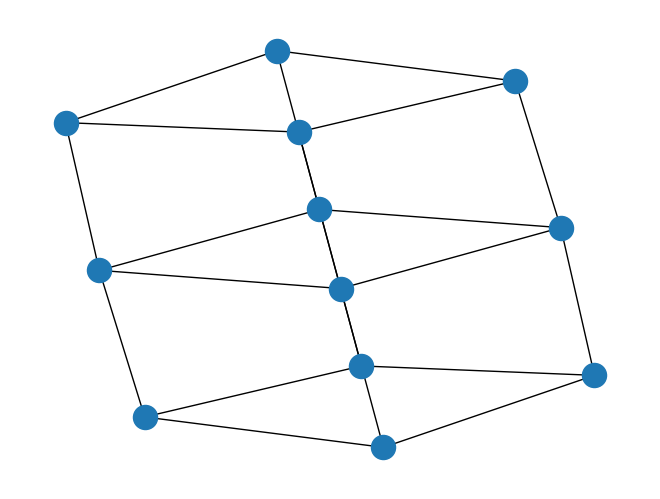

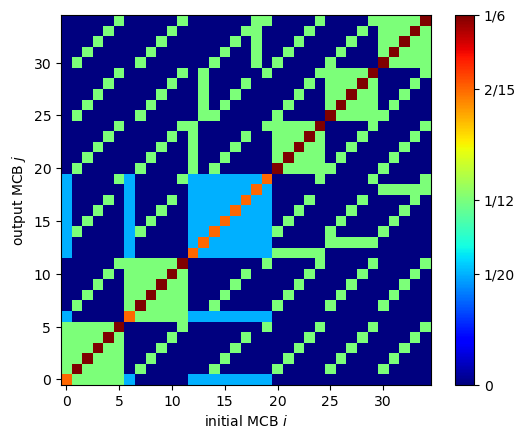

In [3]:
# 2 cubes glued into a prism
G = nx.grid_graph((2,2,3))
Pr = MCB_transition_matrix(G).toarray()
nx.draw_kamada_kawai(G)
plt.figure()
# show transition matrix
plt.imshow(Pr,cmap='jet')
cbar = plt.colorbar(ticks=[0,1/20,1/12,2/15,1/6])
cbar.set_ticklabels([0,'1/20','1/12','2/15','1/6'])
plt.xlim(0-.5,len(Pr)-.5)
plt.xlabel(r'initial MCB $i$')
plt.ylim(0-.5,len(Pr)-.5)
plt.ylabel(r'output MCB $j$')
# make sure row sums are 1 (to be stochastic)
np.sum(Pr,axis=1)

# Example 2: weighted barallene
Barallene has three hexagonal cycles, any pair of which forms an MCB. We modify this graph so that its faces are replaced by $\texttt{sli}$ classes with multiple cycles. There are two versions:
- Version 'a': there are two $\texttt{sli}$ classes with one cycle and one $\texttt{sli}$ class with two cycles. The MCB from both $\texttt{sli}$ classes with one cycle is half as likely.
- Version 'a': there is one $\texttt{sli}$ class with one cycle and two $\texttt{sli}$ classes with two cycles. The MCB with representing both $\texttt{sli}$ classes with two cycle is twice as likely.

This is meant to highlight transition probabilities that use the number of cycles in $\texttt{sli}$ classes.

[1. 1. 1.]


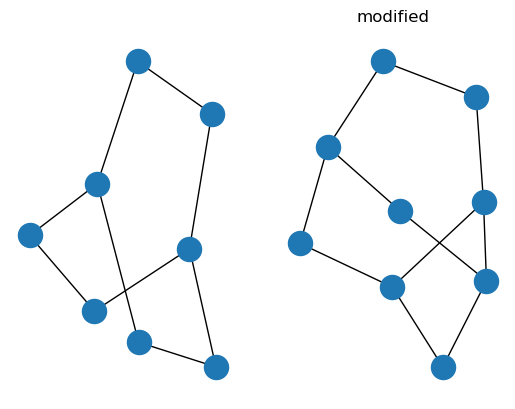

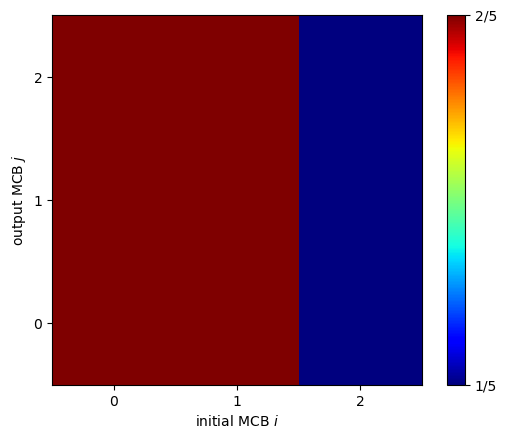

In [4]:
# 2 cubes glued into a prism
version = 'a'
G = nx.cycle_graph(6)
nx.add_path(G,[3,6,7,0])
fig,ax = plt.subplots(1,2)
nx.draw_kamada_kawai(G,ax=ax[0])
if version == 'a':  nx.add_path(G,[5,8,7])
else:               nx.add_path(G,[6,8,0])
Pr = MCB_transition_matrix(G).toarray()
nx.draw_kamada_kawai(G,ax=ax[1])
ax[1].set_title('modified')
plt.title
plt.figure()
# show transition matrix
plt.imshow(Pr,cmap='jet')
if version == 'a':
    cbar = plt.colorbar(ticks=[0,1/5,2/5])
    cbar.set_ticklabels([0,'1/5','2/5'])
else:
    cbar = plt.colorbar(ticks=[0,1/4,2/4])
    cbar.set_ticklabels([0,'1/4','1/2'])
plt.xlim(0-.5,len(Pr)-.5)
plt.xticks(range(3))
plt.xlabel(r'initial MCB $i$')
plt.ylim(0-.5,len(Pr)-.5)
plt.yticks(range(3))
plt.ylabel(r'output MCB $j$')
# make sure row sums are 1 (to be stochastic)
print(np.sum(Pr,axis=1))

# Inverse spectral gap
Now we report the inverse spectral gap and the dimension of the polyhedron space for several small $\tt pi$ classes. These values are roughly equal except for the graphs $K_5,K_6,K_{3,3}$ which are unique that they have linearly dependent small polyhedra.

In [ ]:
# graphs in 3d grid
for m,n,k in ((1,1,1),(1,1,2),(1,1,3),(1,1,4),(1,1,5),(1,1,6),(1,1,7),(1,1,8),(1,2,2),(1,2,3),(1,2,4),(2,2,2)):
    P = MCB_transition_matrix(nx.grid_graph((m+1,n+1,k+1)))
    eigs,_ = scipy.sparse.linalg.eigs(P,k=2)
    print('m,n,k:',m,n,k,'   inverse spectral gap:',1/(eigs[0]-eigs[1]))

m,n,k: 1 1 1    inverse spectral gap: (1-2.7630479232725303e-33j)
m,n,k: 1 1 2    inverse spectral gap: (2.000000000000002+0j)
m,n,k: 1 1 3    inverse spectral gap: (3.0000000000000075+0j)
m,n,k: 1 1 4    inverse spectral gap: (3.999999999999986+0j)
m,n,k: 1 1 5    inverse spectral gap: (5.00000000000002+0j)
m,n,k: 1 1 6    inverse spectral gap: (6.000000000000045+0j)
m,n,k: 1 1 7    inverse spectral gap: (6.999999999999997+0j)
m,n,k: 1 1 8    inverse spectral gap: (7.999999999999957+0j)
m,n,k: 1 2 2    inverse spectral gap: (4.000000000000012+0j)
m,n,k: 1 2 3    inverse spectral gap: (5.999999999999989+0j)
m,n,k: 1 2 4    inverse spectral gap: (8.00000000000012+0j)


In [46]:
# examples from carbon systems
Gtwist = nx.cycle_graph(6)
nx.add_path(Gtwist,[5,6,7,2])
nx.add_path(Gtwist,[1,8,9,4])
P = MCB_transition_matrix(Gtwist)
eigs,_ = scipy.sparse.linalg.eigs(P,k=2)
d = cxc.cycle_decomposition(Gtwist).pi_classes[-1].dim_polyhedra
print('twistane:','  d =',d,'  inverse spectral gap =',1/(eigs[0]-eigs[1]))

Gtwist2 = Gtwist.copy()
nx.add_path(Gtwist2,[1,10,5])
P = MCB_transition_matrix(Gtwist2)
eigs,_ = scipy.sparse.linalg.eigs(P,k=2)
d = cxc.cycle_decomposition(Gtwist2).pi_classes[-1].dim_polyhedra
print('twistane*:',' d =',d,'  inverse spectral gap =',1/(eigs[0]-eigs[1]))

Gtwist3 = Gtwist.copy()
nx.add_path(Gtwist3,[7,10,5])
P = MCB_transition_matrix(Gtwist3)
eigs,_ = scipy.sparse.linalg.eigs(P,k=2)
d = cxc.cycle_decomposition(Gtwist3).pi_classes[-1].dim_polyhedra
print('twistane**:','d =',d,'  inverse spectral gap =',1/(eigs[0]-eigs[1]))

Gtbar = nx.cycle_graph(6)
nx.add_path(Gtbar,[0,6,7,3])
nx.add_path(Gtbar,[1,8,9,4])
nx.add_path(Gtbar,[6,10,11,2])
nx.add_path(Gtbar,[5,12,13,7])
P = MCB_transition_matrix(Gtbar)
eigs,_ = scipy.sparse.linalg.eigs(P,k=2)
d = cxc.cycle_decomposition(Gtbar).pi_classes[-1].dim_polyhedra
print('trapped barallene:','d =',d,'  inverse spectral gap =',1/(eigs[0]-eigs[1]))

twistane:   d = 2   inverse spectral gap = (1.9999999999999991+0j)
twistane*:  d = 2   inverse spectral gap = (1.9999999999999964+0j)
twistane**: d = 2   inverse spectral gap = (1.9999999999999982+0j)
trapped barallene: d = 4   inverse spectral gap = (4.000000000000016+0j)


In [49]:
# other examples
Gtet = nx.complete_graph(4)
Gtet.add_edges_from([[i,4] for i in range(3)]+[[i,5] for i in range(1,4)])
P = MCB_transition_matrix(Gtet)
eigs,_ = scipy.sparse.linalg.eigs(P,k=2)
d = cxc.cycle_decomposition(Gtet).pi_classes[-1].dim_polyhedra
print('tetrahedra:','d =',d,'  inverse spectral gap =',1/(eigs[0]-eigs[1]))

K5 = nx.complete_graph(5)
P = MCB_transition_matrix(K5)
eigs,_ = scipy.sparse.linalg.eigs(P,k=2)
d = cxc.cycle_decomposition(K5).pi_classes[-1].dim_polyhedra
print('K5:','  d =',d,'  inverse spectral gap =',1/(eigs[0]-eigs[1]))

K6 = nx.complete_graph(6)
P = MCB_transition_matrix(K6)
eigs,_ = scipy.sparse.linalg.eigs(P,k=2)
d = cxc.cycle_decomposition(K6).pi_classes[-1].dim_polyhedra
print('K6:','  d =',d, ' inverse spectral gap =',1/(eigs[0]-eigs[1]))

K33 = nx.complete_bipartite_graph(3,3)
P = MCB_transition_matrix(K33)
eigs,_ = scipy.sparse.linalg.eigs(P,k=2)
d = cxc.cycle_decomposition(K33).pi_classes[-1].dim_polyhedra
print('K3,3:','d =',d,'  inverse spectral gap =',1/(eigs[0]-eigs[1]))

tetrahedra: d = 3   inverse spectral gap = (3.000000000000009+0j)
K5:   d = 4   inverse spectral gap = (3.3766459040320784+0j)
K6:   d = 10  inverse spectral gap = (7.2063491245158975+0j)
K3,3: d = 5   inverse spectral gap = (3.3973974019609785+0j)
